In [1]:
import pandas as pd

# 1.데이터 불러오기

df1=pd.read_csv("상권별_공실률.csv", encoding="cp949")
df2=pd.read_csv("상권별_순영업소득.csv", encoding="cp949")
df3=pd.read_csv("상권별_임대료.csv", encoding="cp949")

# 2.데이터 전처리

# df2 파일에서 "항목"란에 불필요한 임대수입,기타수입,운영경비 제거 순영업소득만 남기기

df2_slim = df2[df2["항목"] == "순영업소득 (천원/㎡)"]
 
# <df1,2,3> 상권별(1)에서 서울만 남기고 (전국 제외), 상권별(3)이 "소계"가 아닌 개별 상권만 남기기

df2_slim = df2_slim[
    (df2_slim["상권별(1)"] == "서울") &
    (df2_slim["상권별(3)"] != "소계")
]  
df1_slim = df1[
    (df1["상권별(1)"] == "서울") &
    (df1["상권별(3)"] != "소계")
]
df3_slim = df3[
    (df3["상권별(1)"] == "서울") &
    (df3["상권별(3)"] != "소계")
]

# merge를 위해 컬럼명 통일 (상권별(1)=서울 (2)=넓은권역 (3)=개별상권)
df1_slim = df1_slim.rename(columns={"상권별(3)": "상권명"})
df2_slim = df2_slim.rename(columns={"상권별(3)": "상권명"})
df3_slim = df3_slim.rename(columns={"상권별(3)": "상권명"})

# 필요없는 컬럼 정리

df1_final = df1_slim[["상권명", "2024.3/4", "2024.4/4", "2025.1/4", "2025.2/4", "2025.3/4", "2025.4/4", "2026.1/4"]]
df2_final = df2_slim[["상권명", "2024.3/4", "2024.4/4", "2025.1/4", "2025.2/4", "2025.3/4", "2025.4/4", "2026.1/4"]]
df3_final = df3_slim[["상권명", "2024.3/4", "2024.4/4", "2025.1/4", "2025.2/4", "2025.3/4", "2025.4/4", "2026.1/4"]]

# print(df1_final)

# Wide → Long 변환 (melt)
df1_long = df1_final.melt(id_vars="상권명", var_name="분기", value_name="공실률")
df2_long = df2_final.melt(id_vars="상권명", var_name="분기", value_name="순영업소득")
df3_long = df3_final.melt(id_vars="상권명", var_name="분기", value_name="임대료")


# merge (상권명+분기기준)
final = pd.merge(df1_long, df2_long, on=["상권명","분기"] ,how="left")
final = pd.merge(final, df3_long, on=["상권명","분기"], how="left")


#print(final.shape)  # 413행, 컬럼은 상권명·분기·공실률·순영업소득·임대료 5개
#final.head(5)
final.isnull().sum()

print("======================")

# 3.데이터 분석

# 3-1. 공실률 추이
quarters_order = ["2024.3/4","2024.4/4","2025.1/4","2025.2/4","2025.3/4","2025.4/4","2026.1/4"]

공실률_추이 = final.groupby("분기")["공실률"].mean().reindex(quarters_order)
print(공실률_추이)

# 3. 소수점 출력 정리 (신규)
pd.set_option('display.float_format', '{:.2f}'.format)

# 4. 핵심 분석: 상권별 기간 내 변화량 계산 
quarters_order = ["2024.3/4","2024.4/4","2025.1/4","2025.2/4","2025.3/4","2025.4/4","2026.1/4"]
start_q = "2024.3/4"
end_q = "2026.1/4"

pivot_vac = final.pivot(index="상권명", columns="분기", values="공실률")
pivot_rent = final.pivot(index="상권명", columns="분기", values="임대료")
pivot_noi = final.pivot(index="상권명", columns="분기", values="순영업소득")

변화 = pd.DataFrame({
    "공실률_변화": pivot_vac[end_q] - pivot_vac[start_q],
    "임대료_변화율": (pivot_rent[end_q] - pivot_rent[start_q]) / pivot_rent[start_q] * 100,
    "NOI_변화율": (pivot_noi[end_q] - pivot_noi[start_q]) / pivot_noi[start_q] * 100,
}).reset_index()

# 5. 역설 상권 식별
역설상권 = 변화[
    (변화["공실률_변화"] > 0) &
    (변화["임대료_변화율"].abs() < 1) &
    (변화["NOI_변화율"] > 0)
].sort_values("공실률_변화", ascending=False)

print(f"역설 상권 개수: {len(역설상권)}")
print(역설상권)

# ── 핵심 분석 3가지 ──

# ① 전체 공실률 추이 — 공실률이 상승중
공실률_추이 = final.groupby("분기")["공실률"].mean().reindex(quarters_order).round(2)
print("① 전체 평균 공실률 추이")
print(공실률_추이)

# ② 공실률 변화 vs 임대료 변화 상관관계 — 임대료가 안내려감
corr = 변화["공실률_변화"].corr(변화["임대료_변화율"])
print(f"\n② 공실률-임대료 변화 상관계수: {corr:.3f}")

# ③ 역설군(8) vs 일반군(51) NOI 비교 — "왜 안 내려가는가"
역설_리스트 = 역설상권["상권명"].tolist()
변화["그룹"] = 변화["상권명"].apply(lambda x: "역설군" if x in 역설_리스트 else "일반군")
noi_비교 = 변화.groupby("그룹")["NOI_변화율"].mean().round(2)
print("\n③ 그룹별 평균 NOI 변화율")
print(noi_비교)

print("final")

분기
2024.3/4    4.908475
2024.4/4    4.652542
2025.1/4    4.874576
2025.2/4    4.581356
2025.3/4    5.464407
2025.4/4    5.606780
2026.1/4    5.552542
Name: 공실률, dtype: float64
역설 상권 개수: 8
      상권명  공실률_변화  임대료_변화율  NOI_변화율
15  독산/시흥   11.20     0.32    73.88
33   숙명여대    8.00    -0.88    56.19
37  신촌/이대    5.60    -0.49   133.24
40    연신내    4.80     0.00    14.29
35    신림역    4.10     0.59    20.00
22  미아사거리    3.80     0.25    25.95
42   오류동역    2.60    -0.18    36.54
53    청량리    1.30     0.50    40.73
① 전체 평균 공실률 추이
분기
2024.3/4   4.91
2024.4/4   4.65
2025.1/4   4.87
2025.2/4   4.58
2025.3/4   5.46
2025.4/4   5.61
2026.1/4   5.55
Name: 공실률, dtype: float64

② 공실률-임대료 변화 상관계수: 0.025

③ 그룹별 평균 NOI 변화율
그룹
역설군    50.10
일반군   128.60
Name: NOI_변화율, dtype: float64
final


In [2]:
# 1. 임대료 변동 기준 3분류 정의
def categorize_rent(row):
  if row["임대료_변화율"] >= 1.0:
    return "임대료 상승"
  elif row["임대료_변화율"] <= -1.0:
    return "임대료 하락"
  else:
    return "임대료 유지"


변화["임대료_분류"] = 변화.apply(categorize_rent, axis=1)

# 2. 분류별 상권 수 집계 (순서 고정: 상승 -> 유지 -> 하락)
category_order = ["임대료 상승", "임대료 유지", "임대료 하락"]
rent_counts = 변화["임대료_분류"].value_counts().reindex(category_order).fillna(0)

print("=== 임대료 3분류 상권 수 ===")
print(rent_counts)

# 3. 분류별 평균 NOI 변화율 집계
rent_noi = (
    변화.groupby("임대료_분류")["NOI_변화율"].mean().reindex(category_order).fillna(0)
)

print("\n=== 분류별 평균 NOI 변화율 (%) ===")
print(rent_noi)

=== 임대료 3분류 상권 수 ===
임대료_분류
임대료 상승    35
임대료 유지    19
임대료 하락     5
Name: count, dtype: int64

=== 분류별 평균 NOI 변화율 (%) ===
임대료_분류
임대료 상승   173.44
임대료 유지    32.09
임대료 하락    55.78
Name: NOI_변화율, dtype: float64


In [ ]:
임대료유지 = 변화[변화['임대료_변화율'].abs() < 1].copy()
임대료유지['공실_방향'] = ['공실 증가' if x > 0 else '공실 감소·유지' for x in 임대료유지['공실률_변화']]

noi_공실별 = 임대료유지.groupby('공실_방향')['NOI_변화율'].mean().round(2)
print(noi_공실별)
print("해당 상권 수:", 임대료유지['공실_방향'].value_counts())

공실_방향
공실 감소·유지   18.99
공실 증가      50.10
Name: NOI_변화율, dtype: float64
해당 상권 수: 공실_방향
공실 감소·유지    11
공실 증가        8
Name: count, dtype: int64


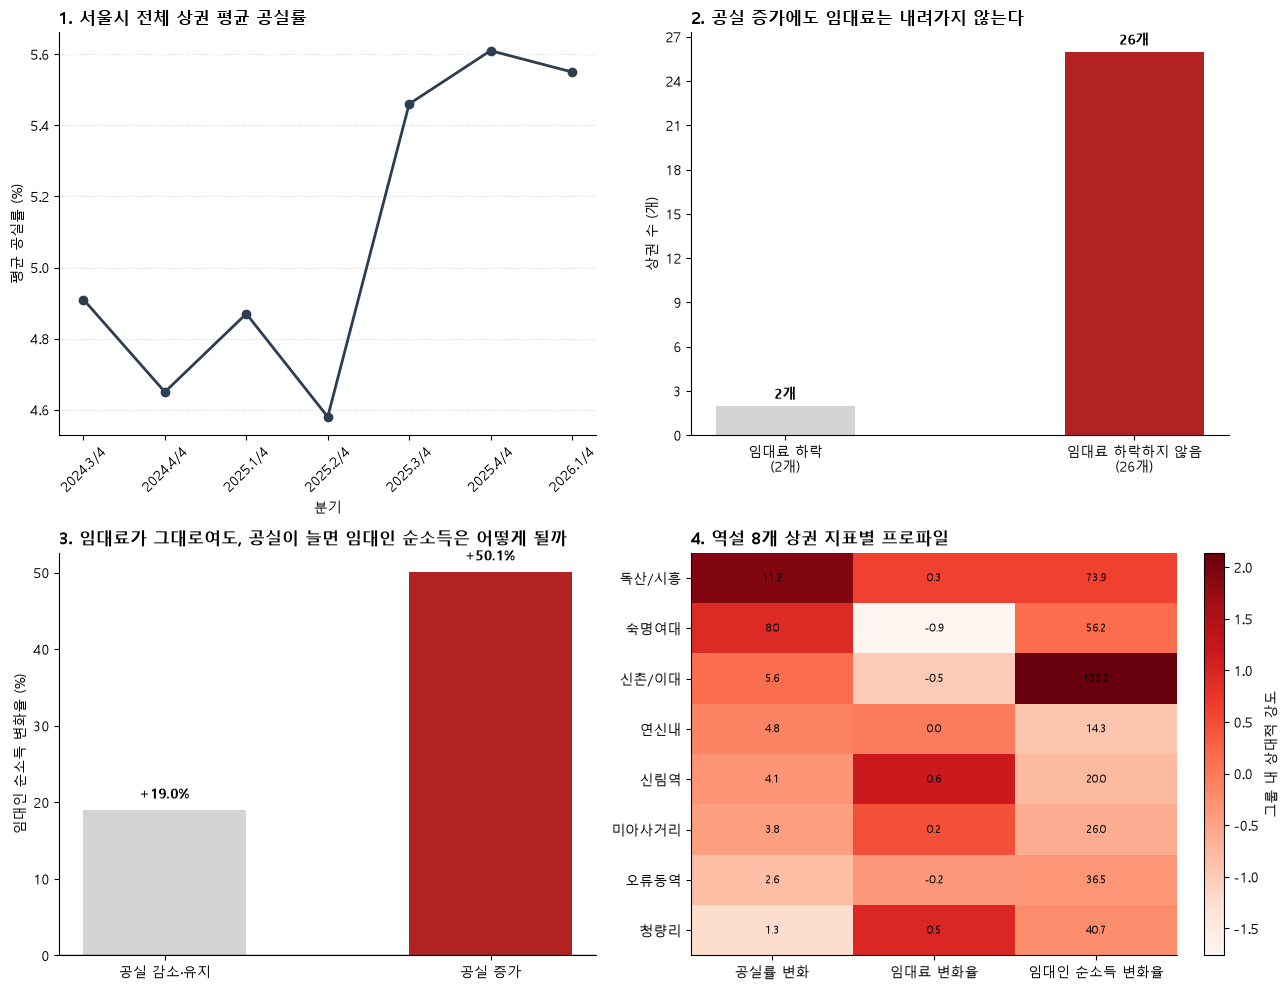

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

plt.rcParams["font.family"] = "Malgun Gothic"   # Mac: 'AppleGothic'
plt.rcParams["axes.unicode_minus"] = False

# ── 데이터 준비 ──

# ② 공실 증가 상권 중, 임대료가 실제로 내려갔는지 여부 (이진 구조)
공실증가 = 변화[변화["공실률_변화"] > 0].copy()
공실증가["임대료_하락여부"] = ["하락" if x < -1 else "하락하지 않음" for x in 공실증가["임대료_변화율"]]

n_하락 = (공실증가["임대료_하락여부"] == "하락").sum()
n_안하락 = (공실증가["임대료_하락여부"] == "하락하지 않음").sum()

# ③ 임대료 거의 안 움직인 상권만 골라, 공실 증감별 임대인 순소득 비교
임대료유지 = 변화[변화["임대료_변화율"].abs() < 1].copy()
임대료유지["공실_방향"] = ["공실 증가" if x > 0 else "공실 감소·유지" for x in 임대료유지["공실률_변화"]]
noi_공실별 = 임대료유지.groupby("공실_방향")["NOI_변화율"].mean().round(2)

# ④ 역설 8개 상권 지표 프로파일
히트맵_data = 역설상권.set_index("상권명")[["공실률_변화", "임대료_변화율", "NOI_변화율"]]
정규화 = (히트맵_data - 히트맵_data.mean()) / 히트맵_data.std()


# ── 시각화: 2x2 배치 ──
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ① 서울시 전체 상권 평균 공실률
axes[0,0].plot(quarters_order, 공실률_추이.values, color="#2C3E50", marker="o", linewidth=2)
axes[0,0].set_title("1. 서울시 전체 상권 평균 공실률", fontsize=12, fontweight="bold", loc="left")
axes[0,0].set_xlabel("분기")
axes[0,0].set_ylabel("평균 공실률 (%)")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].grid(axis="y", linestyle=":", alpha=0.5)

# ② 공실 증가에도 임대료는 내려가지 않는다
bars2 = axes[0,1].bar(
    [f"임대료 하락\n({n_하락}개)", f"임대료 하락하지 않음\n({n_안하락}개)"],
    [n_하락, n_안하락],
    color=["lightgray", "firebrick"], width=0.4
)
axes[0,1].set_title("2. 공실 증가에도 임대료는 내려가지 않는다", fontsize=12, fontweight="bold", loc="left")
axes[0,1].set_ylabel("상권 수 (개)")
axes[0,1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0,1].bar_label(bars2, fmt="%d개", padding=3, fontweight="bold")

# ③ 임대료가 그대로여도, 공실이 늘면 임대인 순소득은 어떻게 될까
bars3 = axes[1,0].bar(noi_공실별.index, noi_공실별.values, color=["lightgray", "firebrick"], width=0.5)
axes[1,0].axhline(0, color="#333333", linewidth=1.0)
axes[1,0].set_title("3. 임대료가 그대로여도, 공실이 늘면 임대인 순소득은 어떻게 될까",
                     fontsize=12, fontweight="bold", loc="left")
axes[1,0].set_ylabel("임대인 순소득 변화율 (%)")
for i, v in enumerate(noi_공실별.values):
    axes[1,0].text(i, v + 1.5, f"{v:+.1f}%", ha="center", fontweight="bold")

# ④ 역설 8개 상권 지표별 프로파일
im = axes[1,1].imshow(정규화.values, cmap="Reds", aspect="auto")
axes[1,1].set_xticks(range(3))
axes[1,1].set_xticklabels(["공실률 변화", "임대료 변화율", "임대인 순소득 변화율"])
axes[1,1].set_yticks(range(len(히트맵_data)))
axes[1,1].set_yticklabels(히트맵_data.index)
for i in range(len(히트맵_data)):
    for j in range(3):
        axes[1,1].text(j, i, f"{히트맵_data.iloc[i,j]:.1f}", ha="center", va="center", fontsize=8)
axes[1,1].set_title("4. 역설 8개 상권 지표별 프로파일", fontsize=12, fontweight="bold", loc="left")
fig.colorbar(im, ax=axes[1,1], label="그룹 내 상대적 강도", fraction=0.046)

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("핵심분석_4종.png", dpi=150)
plt.show()